In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


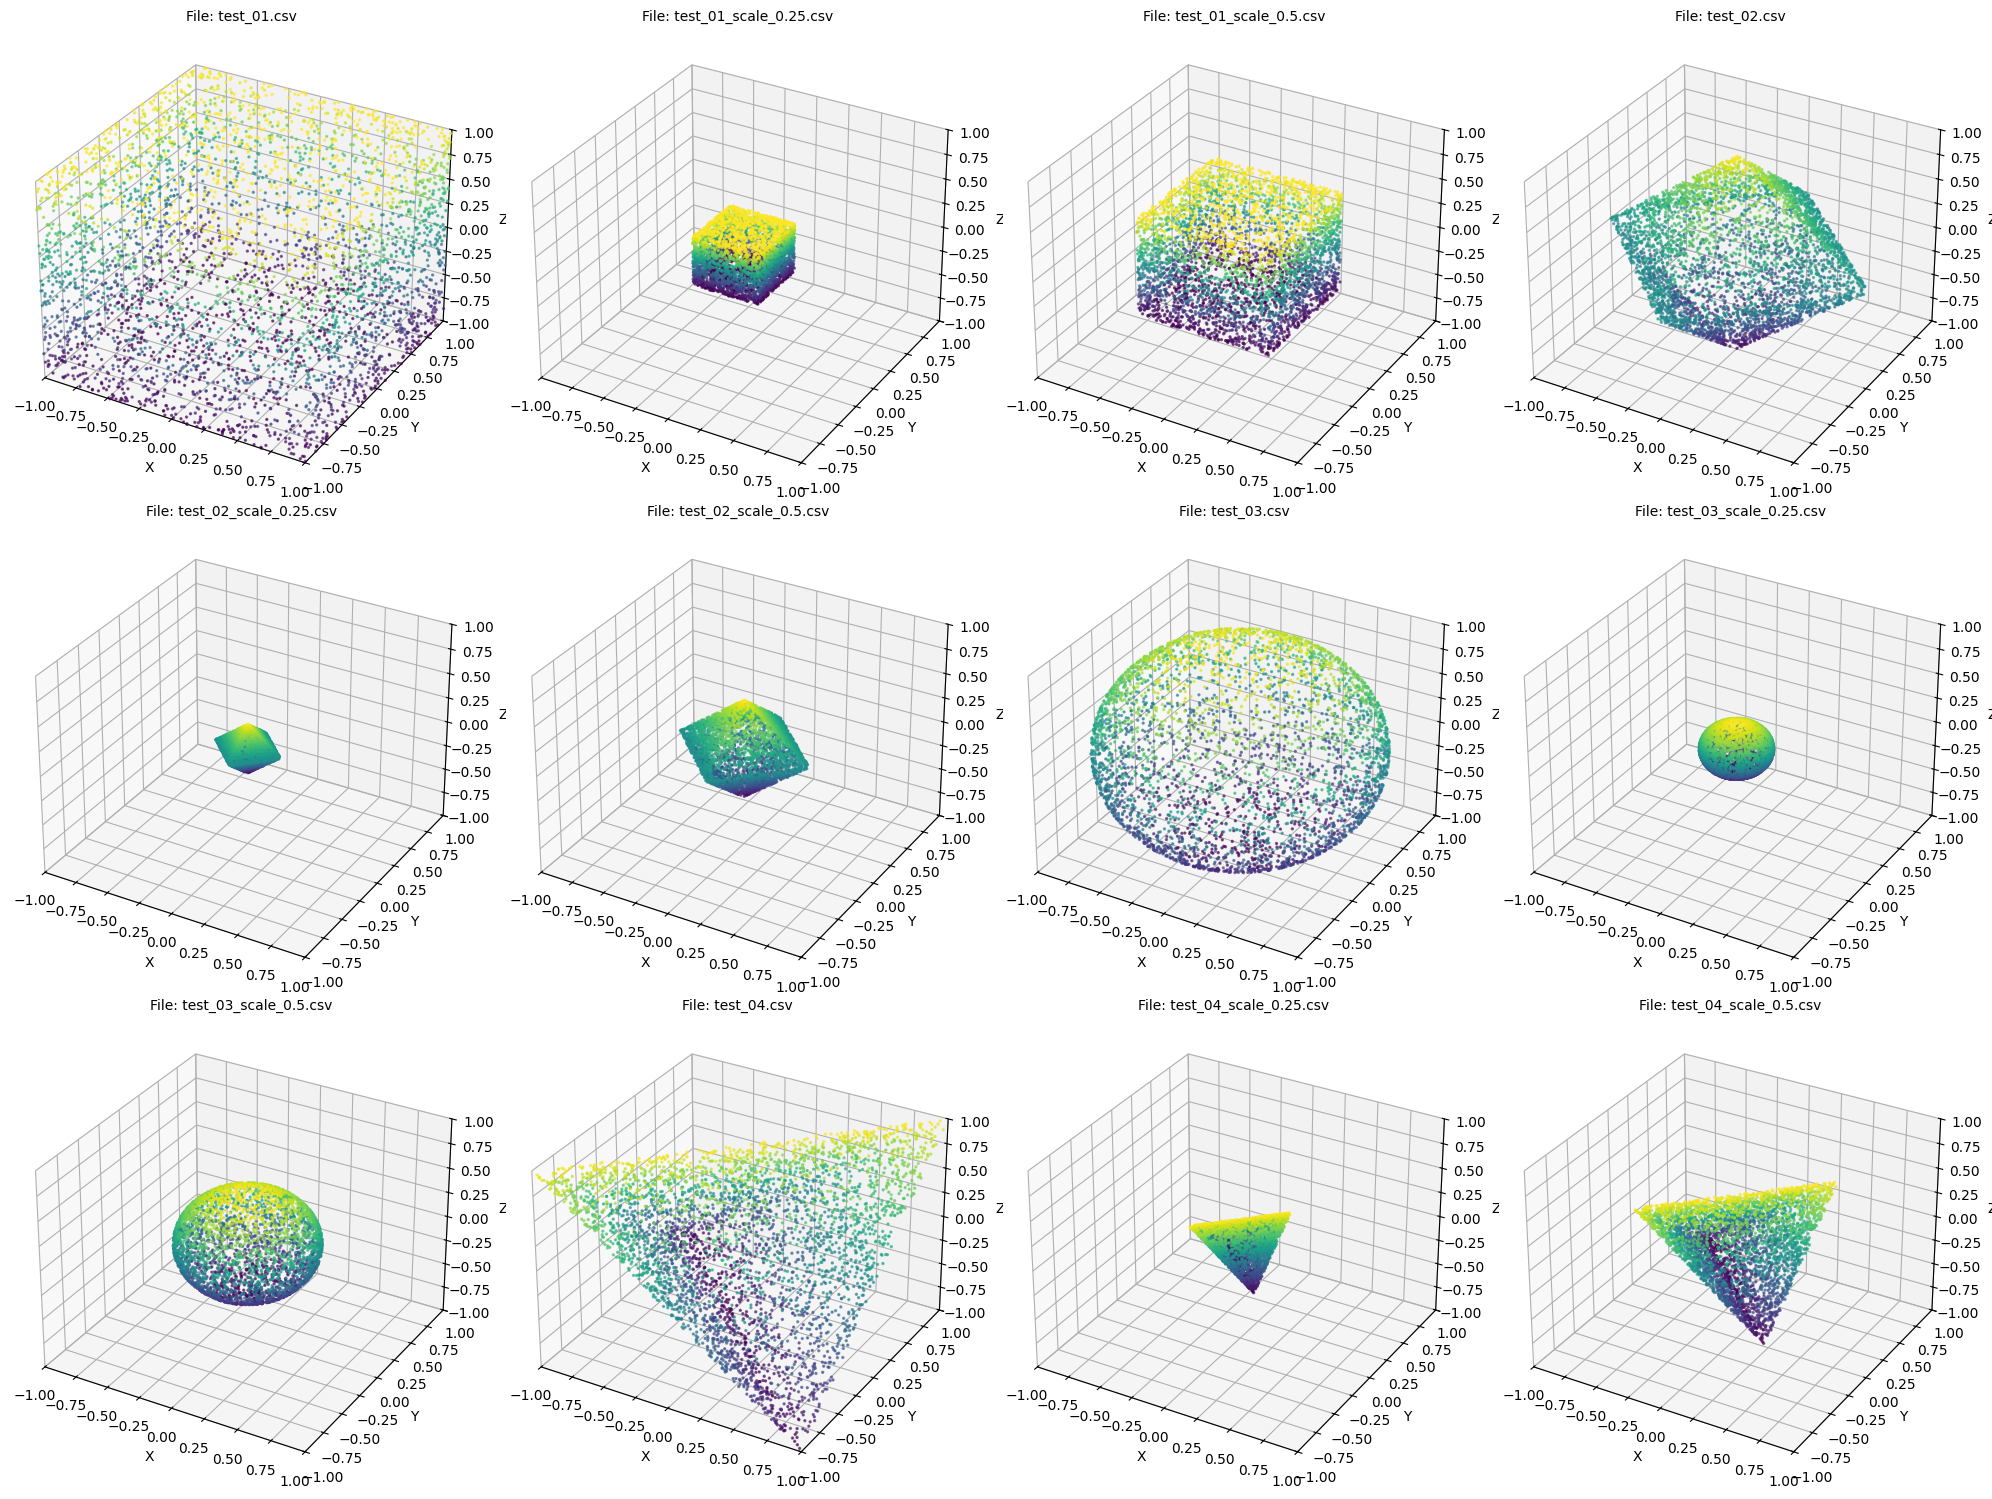

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. パスの設定
folder_path = "/content/drive/MyDrive/output_data_-1_1"  # フォルダパス

# 2. ファイルリストの取得（.csvのみ）
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
csv_files = sorted(csv_files)[:12]  # 最初の12個を選択するように変更

# 3. 可視化の準備 (12個配置するため、3行4列のグラフ領域を作成)
# 全体が収まるように少しサイズを大きく設定しています
fig = plt.figure(figsize=(20, 15))

for i, filename in enumerate(csv_files):
    # ファイルの読み込み
    file_full_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_full_path, header=None)
    
    # データが (N, 3) 形式であることを想定
    points = df.values
    
    # 4. サブプロットの追加 (3行4列の i+1 番目)
    ax = fig.add_subplot(3, 4, i + 1, projection='3d')
    
    # 散布図の描画 (c=points[:, 2] で高さに応じた色分け)
    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                    c=points[:, 2], cmap='viridis', s=2, alpha=0.6)
    
    # タイトルとラベル
    # ファイル名が長いと重なる可能性があるため、フォントサイズを少し小さめにしています
    ax.set_title(f"File: {filename}", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # ★ x, y, zの軸の表示範囲を -1 から 1 に固定
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

# レイアウトの調整
plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import os
import pandas as pd
import random
import numpy as np

# --- 1. エンコーダ・デコーダ・距離関数等の定義 ---
class PointNetEncoder(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.z_dim = z_dim
        self.feature_extractor = nn.Sequential(
            self._conv_bn(3, 64),
            self._conv_bn(64, 128),
            self._conv_bn(128, 256),
            self._conv_bn(256, 512),
            self._conv_bn(512, 1024),
        )
        self.fc_mu = nn.Linear(1024, z_dim)
        self.fc_logvar = nn.Linear(1024, z_dim)

    def _conv_bn(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.max(x, dim=2)[0] # (B, 1024)
        return self.fc_mu(x), self.fc_logvar(x)

class MLPDecoder(nn.Module):
    def __init__(self, z_dim=256, num_points=4096):
        super().__init__()
        self.num_points = num_points
        self.model = nn.Sequential(
            nn.Linear(z_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(True),
            nn.Linear(2048, num_points * 3),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, self.num_points, 3)

class PointCloudVAE(nn.Module):
    def __init__(self, z_dim=3, num_points=4096, num_ext_features=4):
        super().__init__()
        self.encoder = PointNetEncoder(z_dim)
        self.decoder = MLPDecoder(z_dim, num_points)
        
        # 重回帰分析用の線形予測層 (潜在変数3 + 外部変数4 = 入力7)
        self.regressor = nn.Linear(z_dim + num_ext_features, 1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, ext_features=None):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        
        pred_target = None
        if ext_features is not None:
            # 潜在変数と外部説明因子を結合して目的変数を予測
            reg_input = torch.cat([mu, ext_features], dim=1)
            pred_target = self.regressor(reg_input)
            
        return recon, mu, logvar, pred_target

def chamfer_distance(p1, p2):
    p1_norm = torch.sum(p1**2, dim=2, keepdim=True) 
    p2_norm = torch.sum(p2**2, dim=2, keepdim=True).transpose(1, 2)
    dist_matrix = p1_norm + p2_norm - 2 * torch.bmm(p1, p2.transpose(1, 2))
    dist_matrix = torch.clamp(dist_matrix, min=0.0)
    dist_p1_p2 = torch.min(dist_matrix, dim=2)[0]
    dist_p2_p1 = torch.min(dist_matrix, dim=1)[0]
    return dist_p1_p2.sum(dim=1).mean() + dist_p2_p1.sum(dim=1).mean()

In [ ]:
# --- 2. カスタムデータセット ---
class PointCloudCSVDataset(Dataset):
    def __init__(self, folder_path, meta_csv_path, max_points=4096):
        self.points_list = []
        self.ext_features_list = []
        self.targets_list = []
        
        # メタデータの読み込み
        meta_df = pd.read_csv(meta_csv_path)
        meta_dict = {}
        for _, row in meta_df.iterrows():
            filename = str(row.iloc[0])
            features = row.iloc[1:5].values.astype(np.float32)
            target = np.array([row.iloc[5]]).astype(np.float32)
            meta_dict[filename] = (features, target)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found.")
            return

        csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

        for filename in csv_files:
            if filename not in meta_dict:
                continue 
                
            df = pd.read_csv(os.path.join(folder_path, filename), header=None, dtype=np.float32)
            pts = df.values
            if len(pts) >= max_points:
                indices = np.random.choice(len(pts), max_points, replace=False)
                self.points_list.append(torch.from_numpy(pts[indices]).t())
                
                feats, target = meta_dict[filename]
                self.ext_features_list.append(torch.from_numpy(feats))
                self.targets_list.append(torch.from_numpy(target))
                
    def __len__(self):
        return len(self.points_list)

    def __getitem__(self, idx):
        return self.points_list[idx], self.ext_features_list[idx], self.targets_list[idx]

# --- 3. 学習マネージャー ---
class PointCloudTrainer:
    def __init__(self, model, lr=1e-4, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
        
    def train_epoch(self, dataloader, epoch, warmup_epochs, start_points=1024, max_points=4096, gamma=1.0):
        self.model.train()
        total_loss, total_recon, total_kl, total_mse, total_r2 = 0, 0, 0, 0, 0
        
        alpha = min(1.0, epoch / max(1, warmup_epochs))
        curr_points = int(start_points + (max_points - start_points) * alpha)
        curr_points = (curr_points // 32) * 32 
        
        start_beta = 0.01
        max_beta = 1.0
        beta = start_beta + (max_beta - start_beta) * alpha
        
        for batch in dataloader:
            points, ext_features, targets = batch
            points = points.to(self.device)
            ext_features = ext_features.to(self.device)
            targets = targets.to(self.device)
            
            self.optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):
                reconstructed, mu, logvar, pred_targets = self.model(points, ext_features)
                
                target_pts = points.transpose(1, 2)[:, :curr_points, :]
                pred_pts = reconstructed[:, :curr_points, :]
                
                # 1. 復元ロス (Chamfer Distance)
                recon_loss = chamfer_distance(pred_pts, target_pts)
                
                # 2. KLロス
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
                
                # 3. 回帰ロス (最適化用: MSE)
                mse_loss = F.mse_loss(pred_targets, targets)
                
                # 4. 評価用指標 (R2スコア) - 勾配計算には含めない
                ss_res = torch.sum((targets - pred_targets) ** 2)
                ss_tot = torch.sum((targets - torch.mean(targets)) ** 2)
                r2 = 1 - ss_res / (ss_tot + 1e-8)
                
                # トータルロス (gamma で MSEロスの影響力を調整)
                loss = 1.0 * recon_loss + 5.0 * beta * kl_loss + gamma * mse_loss
            
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            total_mse += mse_loss.item()
            total_r2 += r2.item()
            
        n_batches = len(dataloader)
        return (total_loss / n_batches, total_recon / n_batches, 
                total_kl / n_batches, total_mse / n_batches, 
                total_r2 / n_batches, beta, curr_points)

# --- 4. メイン実行 ---
# 設定
z_dim = 3
num_points = 4096
batch_size = 12  # ※バッチサイズは16以上を推奨
num_epochs = 5000
lr = 5e-5
warmup_epochs = 4000
gamma = 100.0 # MSEロスの重み（スケールが大きい場合は 0.1 等に調整）

# --- パス指定 ---
# 実際の環境に合わせて適切に設定してください
#folder_path = "your_csv_folder"
meta_csv_path = "/content/drive/MyDrive/meta_data/meta_data_update.csv"

# 準備
dataset = PointCloudCSVDataset(folder_path, meta_csv_path, max_points=num_points)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

vae = PointCloudVAE(z_dim=z_dim, num_points=num_points, num_ext_features=4)
trainer = PointCloudTrainer(vae, lr=lr)

print(f"Starting Warmup Training: 0 -> {warmup_epochs} epochs")

for epoch in range(num_epochs):
    avg_loss, avg_recon, avg_kl, avg_mse, avg_r2, current_beta, curr_p = trainer.train_epoch(
        dataloader, epoch, warmup_epochs, start_points=256, max_points=num_points, gamma=gamma
    )
    
    # ログ出力 (MSEとR2を両方表示)
    if (epoch + 1) == 1 or (epoch + 1) % 500 == 0:
        status = "WARMUP" if epoch < warmup_epochs else "STABLE"
        print(f"[{status}] Epoch [{epoch+1:>4}/{num_epochs}] Pts: {curr_p:>4} | "
              f"Loss: {avg_loss:8.4f} | Recon: {avg_recon:8.4f} | KL: {avg_kl:8.4f} | "
              f"MSE: {avg_mse:8.4f} | R2_Score: {avg_r2:6.4f}")


# ==========================================
# 追加：学習完了後の潜在変数（mu）抽出と表示
# ==========================================
print("\n--- Training Completed ---")
print("Extracting Latent Variables (mu)...")

# 1. 評価用にDataloaderを作り直す (shuffle=False, drop_last=False)
eval_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False)

# 2. モデルを評価モードに切り替え
vae.eval()

# 潜在変数をまとめて保持したい場合のためのリスト
all_latent_vectors = []
all_targets = []

# 3. 勾配計算をオフにしてメモリを節約
with torch.no_grad():
    for i, batch in enumerate(eval_dataloader):
        points, ext_features, targets = batch
        points = points.to(trainer.device)
        
        # エンコーダに点群を入力し、潜在変数(mu)を取得
        # ※ 回帰の結果ではなく、元の点群の次元圧縮結果である mu を取得します
        mu, _ = vae.encoder(points)
        
        # CPU上のNumPy配列に変換
        mu_np = mu.cpu().numpy()
        targets_np = targets.numpy()
        
        print(f"\n[Batch {i+1}] Latent Variables (mu):")
        print(mu_np)
        
        # リストに保存 (後でCSV保存などに使えるように)
        all_latent_vectors.append(mu_np)
        all_targets.append(targets_np)

# (オプション) 全てのバッチのデータを1つのNumPy配列に結合
final_latent_array = np.concatenate(all_latent_vectors, axis=0)
final_targets_array = np.concatenate(all_targets, axis=0)

print(f"\nTotal Extracted Latent Variables Shape: {final_latent_array.shape}")

/tmp/ipython-input-835314833.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
/tmp/ipython-input-835314833.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):


Starting Warmup Training: 0 -> 4000 epochs
[WARMUP] Epoch [   1/5000] Pts:  256 | Loss: 19868.3926 | Recon:  41.2930 | KL:   7.9710 | MSE: 198.2670 | R2_Score: -35.8246
[WARMUP] Epoch [ 500/5000] Pts:  704 | Loss: 507.1833 | Recon:   2.5529 | KL: 699.0210 | MSE:   0.3803 | R2_Score: 0.9294
[WARMUP] Epoch [1000/5000] Pts: 1184 | Loss: 812.9362 | Recon:   3.8148 | KL: 604.2804 | MSE:   0.3186 | R2_Score: 0.9408
[WARMUP] Epoch [1500/5000] Pts: 1664 | Loss: 1005.3004 | Recon:   4.8037 | KL: 498.5479 | MSE:   0.5076 | R2_Score: 0.9057
[WARMUP] Epoch [2000/5000] Pts: 2144 | Loss: 1097.8862 | Recon:   5.4933 | KL: 409.7155 | MSE:   0.5837 | R2_Score: 0.8916
[WARMUP] Epoch [2500/5000] Pts: 2624 | Loss: 1143.2822 | Recon:   5.7780 | KL: 341.5669 | MSE:   0.6413 | R2_Score: 0.8809
[WARMUP] Epoch [3000/5000] Pts: 3104 | Loss: 1153.1832 | Recon:   5.8654 | KL: 283.3725 | MSE:   0.8148 | R2_Score: 0.8487
[WARMUP] Epoch [3500/5000] Pts: 3584 | Loss: 1156.9773 | Recon:  14.3523 | KL: 246.1425 | MSE: 

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_trained_reconstructions(vae, dataloader):
    """
    学習データから得られた実際の潜在変数を使って再構成を表示する
    """
    vae.eval()
    device = next(vae.parameters()).device
    
    # 1. データの取得（1バッチ分）
    with torch.no_grad():
        batch = next(iter(dataloader)) # (B, 3, N)
        batch = batch.to(device)
        
        # エンコーダで実際の潜在変数(mu)を取得
        mu, _ = vae.encoder(batch)
        # そのmuを使ってデコード（再構成）
        reconstructed_points = vae.decoder(mu).cpu().numpy()
        
    num_samples = reconstructed_points.shape[0]
    mu_np = mu.cpu().numpy()

    # グリッドのサイズを計算 (例: 4サンプルなら 2x2)
    cols = int(np.ceil(np.sqrt(num_samples)))
    rows = int(np.ceil(num_samples / cols))

    fig = plt.figure(figsize=(cols * 5, rows * 5))
    
    for i in range(num_samples):
        ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
        points = reconstructed_points[i]
        
        # 3D散布図
        # c=points[:, 2] で高さ（Z軸）に応じて色付け
        sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                        s=2, c=points[:, 2], cmap='viridis', alpha=0.6)
        
        # タイトルにこのデータの潜在変数の値を表示
        mu_str = ", ".join([f"{val:.2f}" for val in mu_np[i]])
        ax.set_title(f"Reconstruction {i+1}\nLatent (mu): [{mu_str}]", fontsize=10)
        
        # 軸の範囲設定（データが-1〜1の範囲なので少し広めに設定）
        ax.set_xlim([-1.1, 1.1])
        ax.set_ylim([-1.1, 1.1])
        ax.set_zlim([-1.1, 1.1])

# メモリを -1, 0, 1 に設定
        ticks = [-1.0, 0.0, 1.0]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_zticks(ticks)

        # 軸のメモリを消す（見た目スッキリ）
#        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# --- 実行 ---
# 学習が終わった後に呼び出してください
visualize_trained_reconstructions(vae, dataloader)

AttributeError: 'list' object has no attribute 'to'

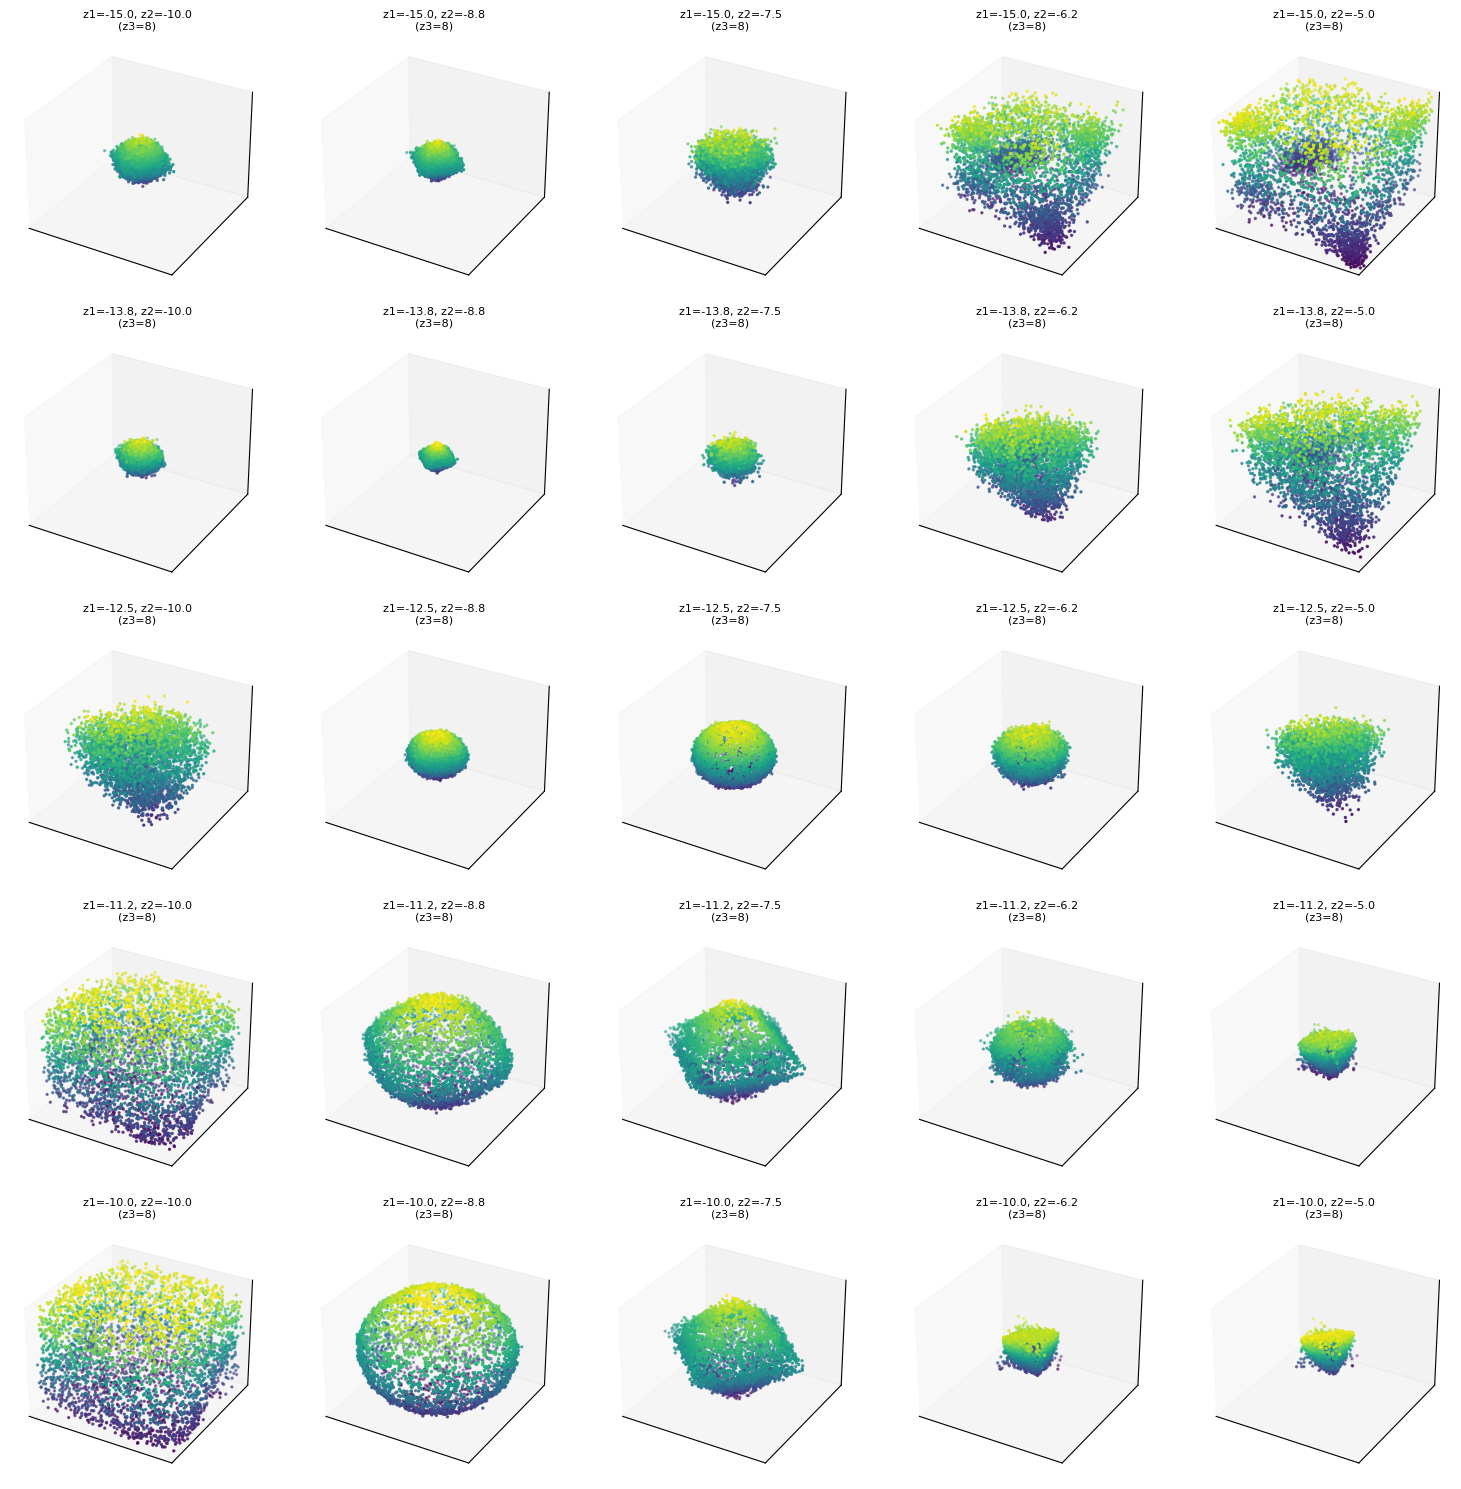

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch  # 元のコードで省略されていましたが、念のため追加しています

def visualize_latent_space(decoder, z_dim, z1_range, z2_range, z1_steps, z2_steps, z3_value=0.0):
    # モデルが現在どのデバイスにあるか取得
    device = next(decoder.parameters()).device
    
    z1_values = np.linspace(z1_range[0], z1_range[1], z1_steps)
    z2_values = np.linspace(z2_range[0], z2_range[1], z2_steps)

    fig = plt.figure(figsize=(15, 15))
    plot_index = 1
    
    for z1 in z1_values:
        for z2 in z2_values:
            # デバイスを指定してテンソルを作成
            z = torch.zeros((1, z_dim), dtype=torch.float32).to(device)
            z[0, 0] = z1
            z[0, 1] = z2
            
            # --- 修正部分: z3_valueを3つ目の次元に代入 ---
            if z_dim >= 3:
                z[0, 2] = z3_value
            # ----------------------------------------------

            with torch.no_grad():
                generated_points = decoder(z).squeeze().cpu().numpy()

            ax = fig.add_subplot(z1_steps, z2_steps, plot_index, projection="3d")
            sc = ax.scatter(generated_points[:, 0], generated_points[:, 1], generated_points[:, 2], 
                            s=2, c=generated_points[:, 2], cmap='viridis')

            # タイトルにz3の値も表示するように変更
            ax.set_title(f"z1={z1:.1f}, z2={z2:.1f}\n(z3={z3_value})", fontsize=8)
            
            # 軸の範囲
            ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

            plot_index += 1

    plt.tight_layout()
    plt.show()

# --- 実行部分 ---
vae.eval() 

visualize_latent_space(
    decoder=vae.decoder,
    z_dim=3, 
    z1_range=[-15, -10], 
    z2_range=[-10, -5], 
    z1_steps=5, 
    z2_steps=5,
    z3_value=8  # ★ ここで好きな固定値を指定できます（デフォルトは0.0）
)